In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
# Построение OLS-модели (ноутбук автономный)
X_ols = sm.add_constant(da[predictors])
model = sm.OLS(da['BI'], X_ols).fit()
residuals = model.resid
fitted = model.fittedvalues
print(f'Размер остатков: {len(residuals)}')

Размер остатков: 164


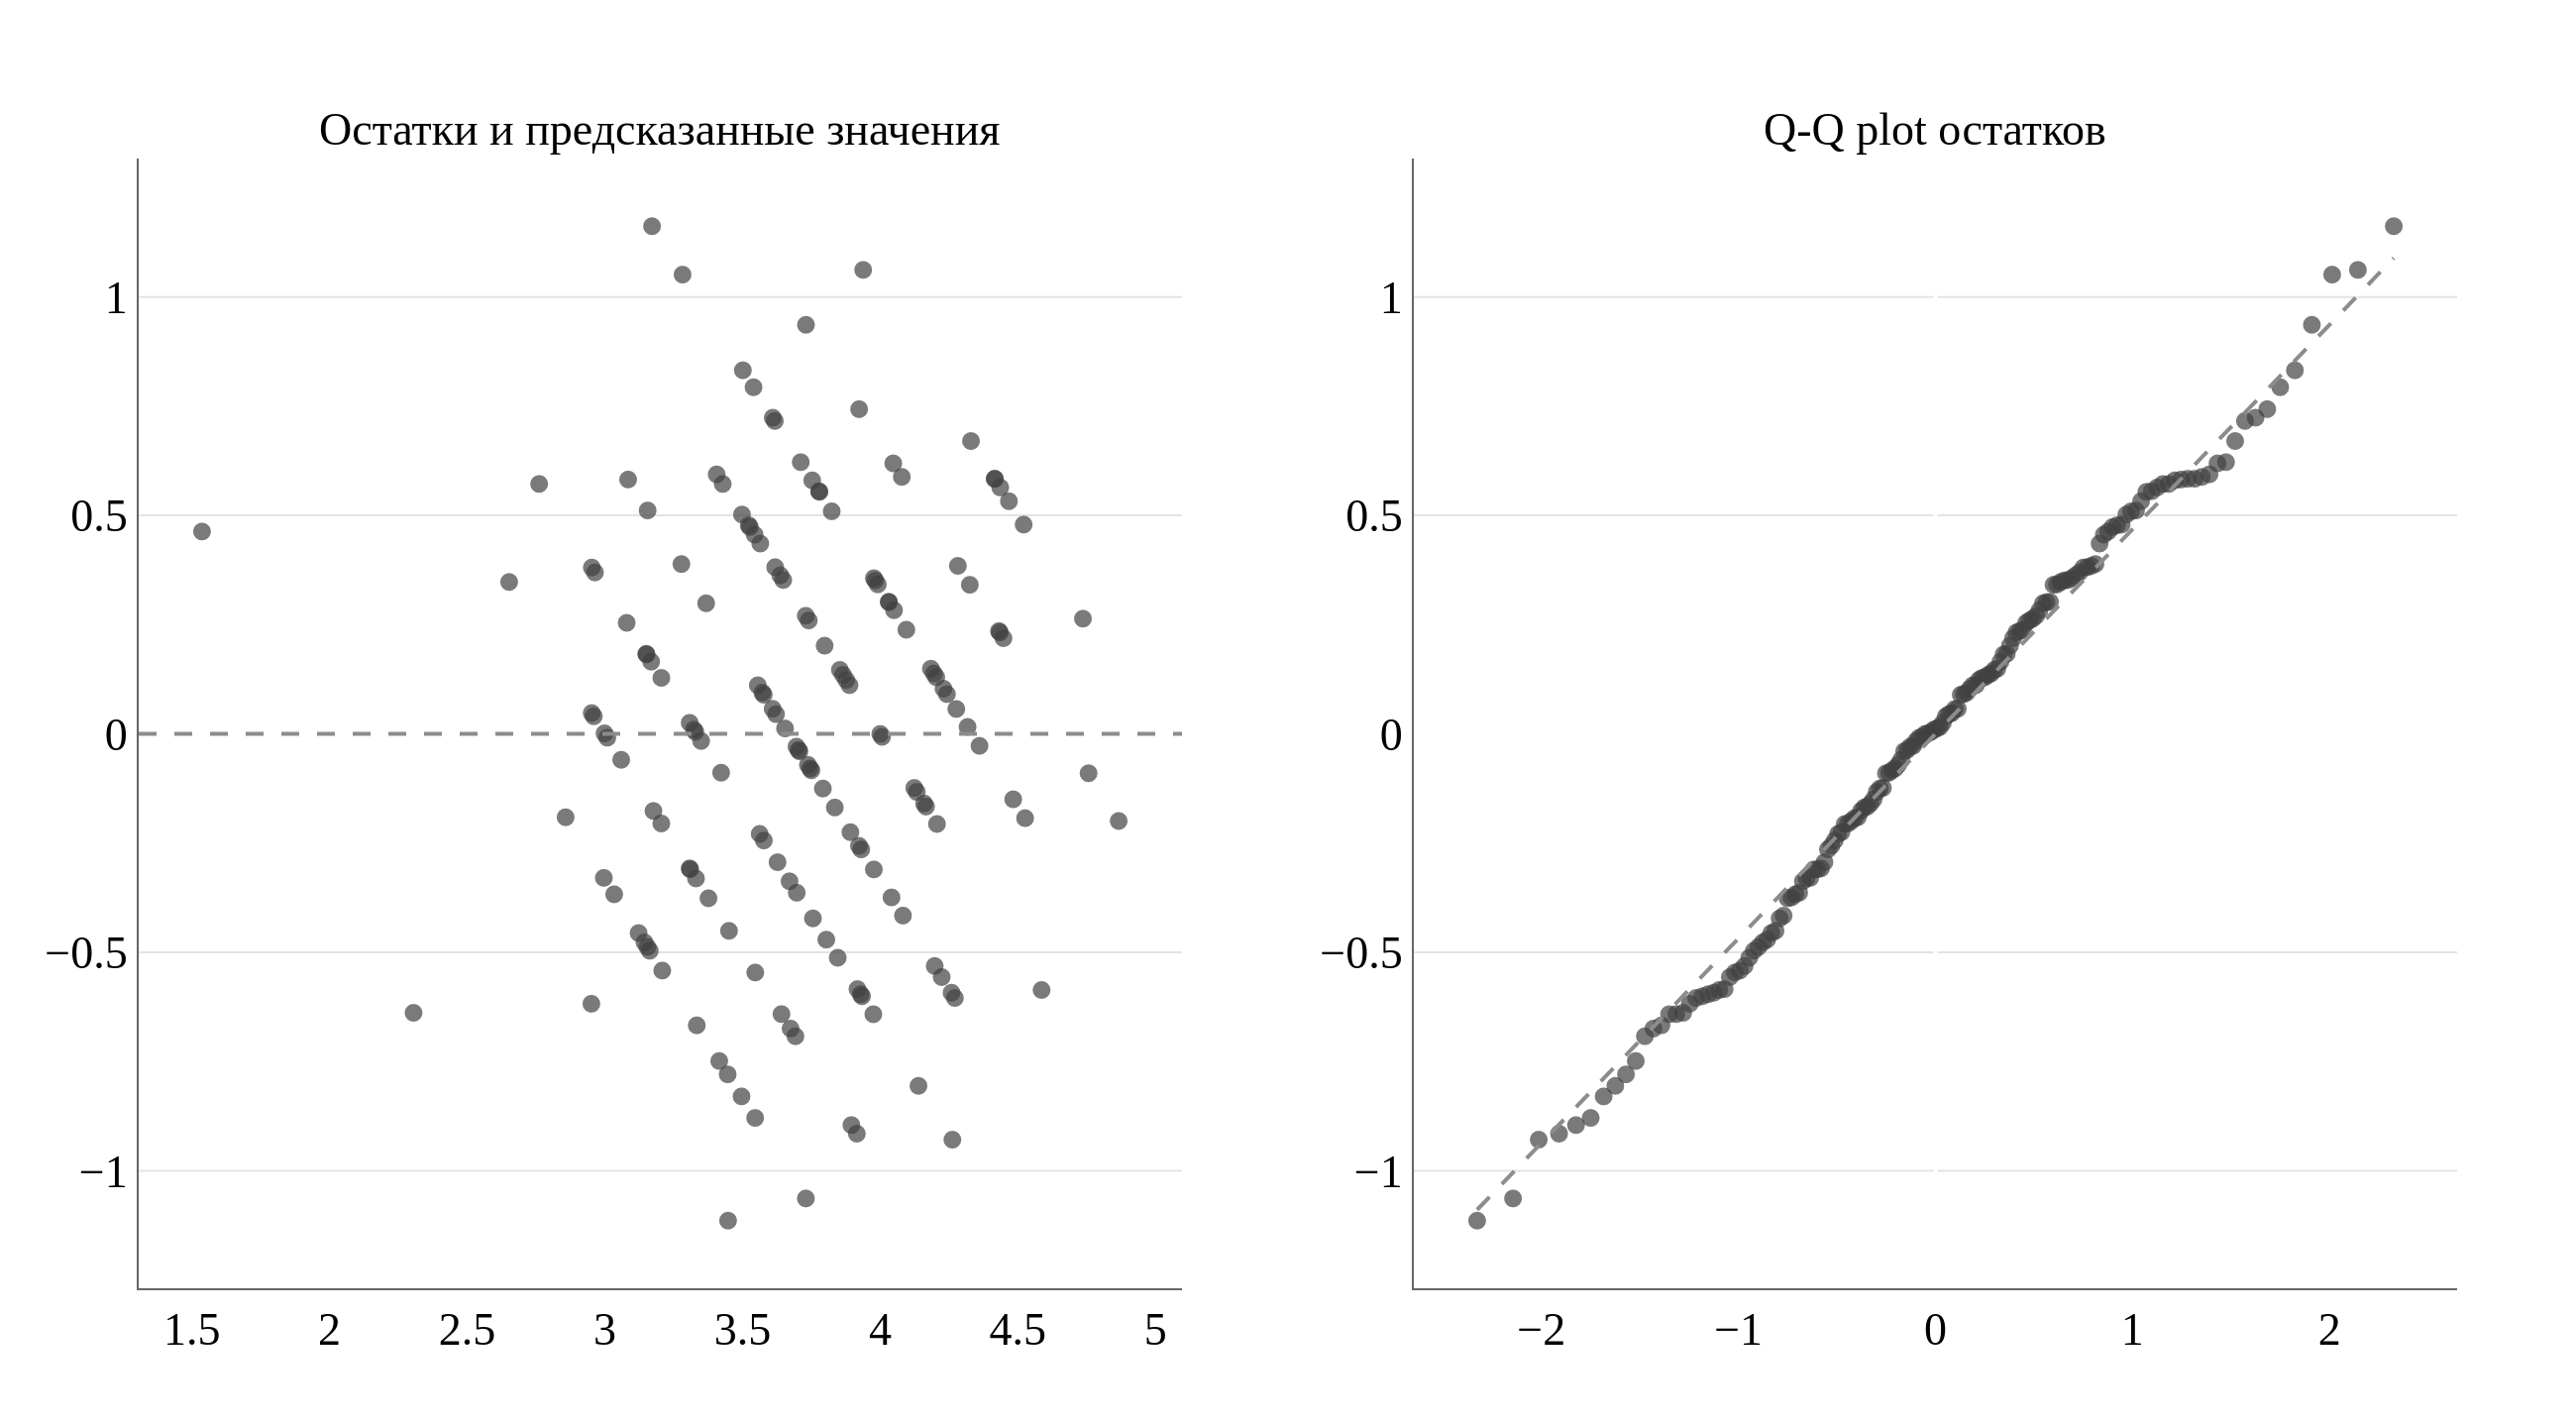

Shapiro-Wilk для остатков: W = 0.9919, p = 0.4846


In [3]:
residuals = model.resid
fitted = model.fittedvalues

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Остатки и предсказанные значения', 'Q-Q plot остатков')
)

fig.add_trace(
    go.Scatter(
        x=fitted,
        y=residuals,
        mode='markers',
        marker=dict(color=PRIMARY, size=9, opacity=0.7),
        showlegend=False
    ),
    row=1, col=1
)
fig.add_hline(y=0, line_dash='dash', line_color=ACCENT, row=1, col=1)

sorted_res = np.sort(residuals)
theoretical = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_res)))

fig.add_trace(
    go.Scatter(
        x=theoretical,
        y=sorted_res,
        mode='markers',
        marker=dict(color=PRIMARY, size=9, opacity=0.7),
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=[theoretical.min(), theoretical.max()],
        y=[theoretical.min() * residuals.std(), theoretical.max() * residuals.std()],
        mode='lines',
        line=dict(color=ACCENT, dash='dash'),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    height=720,
    width=1300,
    margin=dict(l=70, r=60, t=80, b=70)
)

for ann in fig['layout']['annotations']:
    ann['font'] = dict(size=23, family='Times New Roman', color='#000000')

fig.update_xaxes(
    showgrid=False,
    linecolor=AXIS_COLOR,
    linewidth=1,
    tickfont=dict(size=23)
)
fig.update_yaxes(
    showgrid=True,
    gridcolor=GRID_COLOR,
    linecolor=AXIS_COLOR,
    linewidth=1,
    tickfont=dict(size=23)
)

fig.show()

w_res, p_res = stats.shapiro(residuals)
print(f'Shapiro-Wilk для остатков: W = {w_res:.4f}, p = {p_res:.4f}')

In [4]:
print('Вывод:')
print('Диагностика остатков не указывает на критические нарушения предпосылок линейной регрессии.')

if p_res >= 0.05:
    print('Распределение остатков не отличается от нормального на стандартном уровне значимости.')
else:
    print('Наблюдаются отклонения от нормальности остатков, поэтому результаты модели следует интерпретировать с осторожностью.')


Вывод:
Диагностика остатков не указывает на критические нарушения предпосылок линейной регрессии.
Распределение остатков не отличается от нормального на стандартном уровне значимости.
